# Brain tumor detection in MRI scans with classical image processing

This notebook walks through the three pipelines step by step on real scans and
evaluates them on a held-out test set.

| | Segmentation | Features | Classifier |
|---|---|---|---|
| **Pipeline 1** (paper's method) | K-Means (k=4) → Otsu | GLCM texture (7) | RBF SVM |
| **Pipeline 2** | K-Means (k=4) | GLCM texture (7) | RBF SVM |
| **Pipeline 3** | Otsu | HOG (8100) | RBF SVM |

All pipelines share the same pre-processing: grayscale → 3×3 median blur →
histogram equalization → resize to 128×128. Every image-processing step is
implemented from scratch in [`src/brain_tumor`](../src/brain_tumor).

For the more robust nested cross-validation estimate, run `python run_experiments.py`
(see the [README](../README.md)).

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from brain_tumor.classification import holdout_evaluation
from brain_tumor.data import CLASS_NAMES, load_dataset
from brain_tumor.features import GLCM_FEATURE_NAMES, image_gradients
from brain_tumor.pipelines import PIPELINES
from brain_tumor.preprocessing import preprocess
from brain_tumor.segmentation import kmeans_intensity, otsu_binarize, quantize_kmeans
from brain_tumor.visualization import plot_confusion_matrices, plot_pipeline_stages

DATA_DIR = Path(os.environ.get("BRAIN_TUMOR_DATA", "../data/brain_tumor_dataset"))

## 1. Data

253 MRI scans in two folders, `yes` (tumor) and `no` (no tumor). 25 of them duplicate
another file, so they are removed before splitting. Otherwise a test image could
also appear in the training set.

In [2]:
dataset = load_dataset(DATA_DIR)
print(f"{len(dataset)} unique images: {dataset.class_counts()}")
print(f"{len(dataset.duplicates)} duplicates removed, e.g.:")
for dropped, kept in dataset.duplicates[:3]:
    print(f"  {dropped.parent.name}/{dropped.name}  ==  {kept.parent.name}/{kept.name}")

228 unique images: {'no tumor': 87, 'tumor': 141}
25 duplicates removed, e.g.:
  no/27 no.jpg  ==  no/17 no.jpg
  no/41 no.jpg  ==  no/40 no.jpg
  no/42 no.jpg  ==  no/13 no.jpg


## 2. Pre-processing and segmentation, stage by stage

From left to right: the original scan, each pre-processing step, the K-Means
quantisation used by Pipelines 1 and 2, the Otsu masks used by Pipelines 1 and 3,
and the gradient magnitude that HOG summarises.

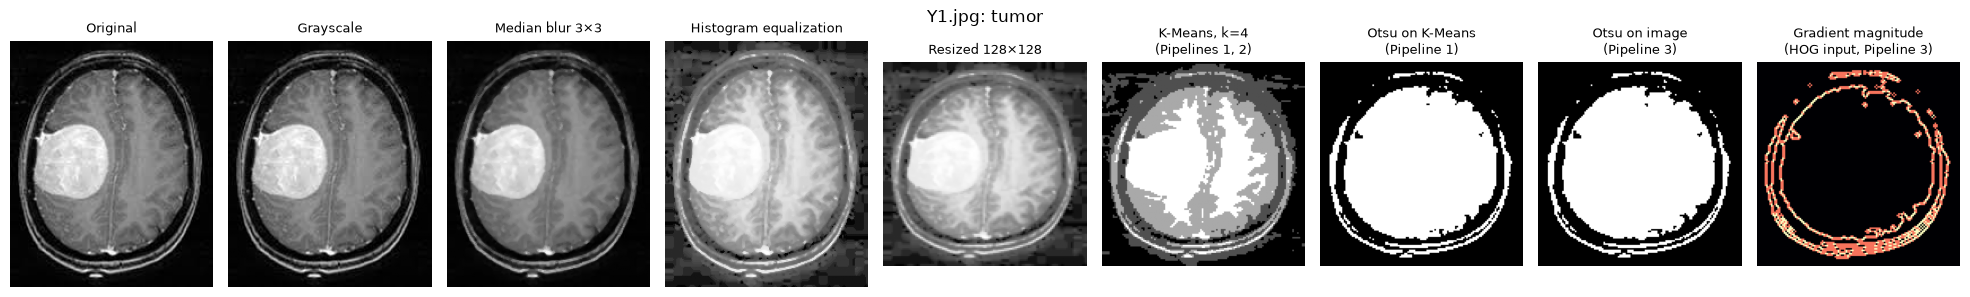

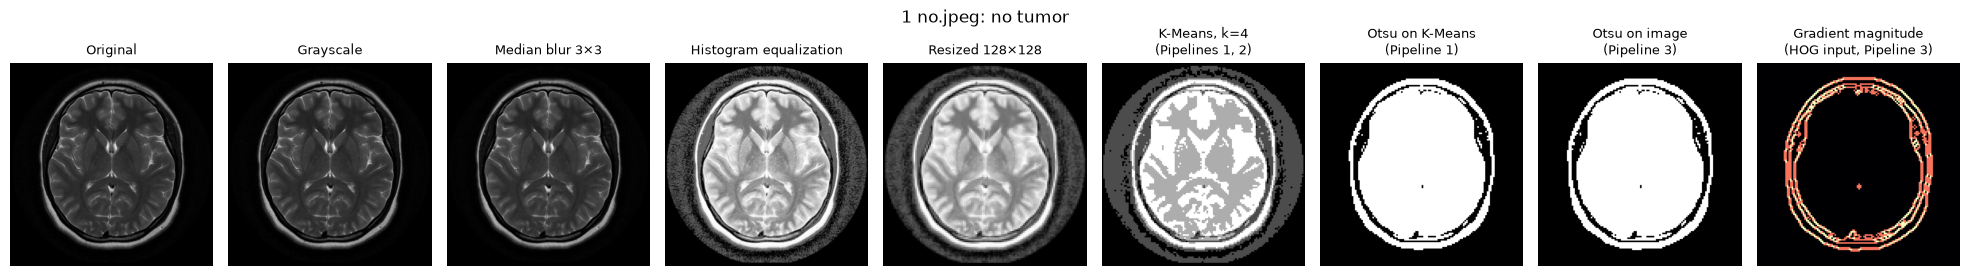

In [3]:
tumor_example = int(np.flatnonzero(dataset.labels == 1)[0])
healthy_example = int(np.flatnonzero(dataset.labels == 0)[0])

for index in (tumor_example, healthy_example):
    fig = plot_pipeline_stages(dataset.images[index])
    fig.suptitle(f"{dataset.paths[index].name}: {CLASS_NAMES[dataset.labels[index]]}", y=1.05)
    plt.show()

In [4]:
images = [preprocess(image) for image in dataset.images]
print(f"Pre-processed {len(images)} images to shape {images[0].shape}")

Pre-processed 228 images to shape (128, 128)


### K-Means clusters

Clusters are sorted by intensity, so label 0 is always the background. The other
three clusters split the brain into intensity bands. Note that these bands are
not anatomical classes: K-Means only sees pixel intensities, so it cannot tell
tumor tissue from bright healthy tissue.

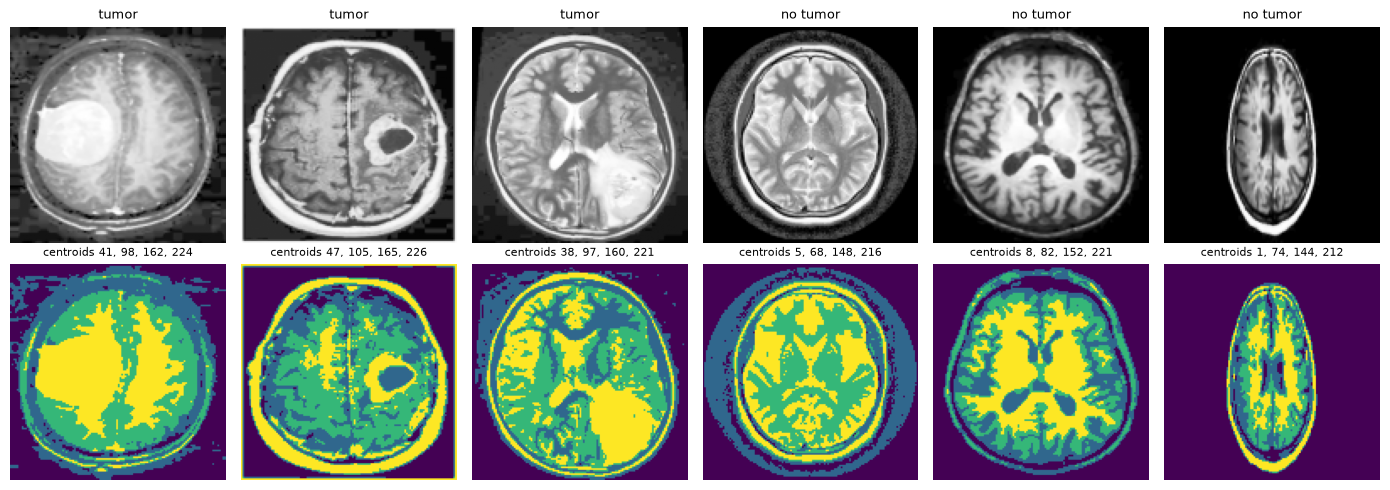

In [5]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
sample = np.r_[np.flatnonzero(dataset.labels == 1)[:3], np.flatnonzero(dataset.labels == 0)[:3]]
for column, index in enumerate(sample):
    labels, centroids = kmeans_intensity(images[index], k=4)
    axes[0, column].imshow(images[index], cmap="gray")
    axes[0, column].set_title(CLASS_NAMES[dataset.labels[index]], fontsize=9)
    axes[1, column].imshow(labels, cmap="viridis")
    axes[1, column].set_title("centroids " + ", ".join(f"{c:.0f}" for c in centroids), fontsize=8)
for ax in axes.ravel():
    ax.axis("off")
fig.tight_layout()
plt.show()

## 3. Feature extraction

**GLCM** (Pipelines 1 and 2): co-occurrence statistics of neighbouring pixels in
four directions (0°, 45°, 90°, 135°), averaged, plus the intensity mean and
standard deviation.

**HOG** (Pipeline 3): histograms of gradient orientations in 8×8 cells, normalised
over 2×2 blocks, which gives 15 × 15 × 36 = 8100 values per image.

In [6]:
features = {pipeline.key: pipeline.transform(images) for pipeline in PIPELINES}
for pipeline in PIPELINES:
    print(f"{pipeline.name} ({pipeline.steps}): feature matrix {features[pipeline.key].shape}")

print("\nGLCM features of the first five images (Pipeline 2):")
print(" ".join(f"{name:>12}" for name in GLCM_FEATURE_NAMES))
for row in features["pipeline_2"][:5]:
    print(" ".join(f"{value:12.4g}" for value in row))

Pipeline 1 (K-Means → Otsu → GLCM): feature matrix (228, 7)
Pipeline 2 (K-Means → GLCM): feature matrix (228, 7)
Pipeline 3 (Otsu → HOG): feature matrix (228, 8100)

GLCM features of the first five images (Pipeline 2):
        mean          std     contrast      entropy       energy  homogeneity  correlation
       98.23        79.87         1276        2.865       0.1731       0.8052       0.8995
       96.16        81.98         1053        2.744       0.1982       0.8133       0.9215
       39.35        69.29         1023        1.806        0.514        0.882       0.8944
       54.88        77.02         1152        2.167       0.3962       0.8602       0.9035
       81.92        80.33        887.9        2.535       0.2386       0.8583       0.9313


## 4. Classification

Each pipeline's features are standardised and classified with an RBF-kernel SVM.
`C`, `gamma` and `class_weight` are tuned by 5-fold grid search on the 80 % training
split only. The model is then evaluated once on the stratified 20 % test split.

In [7]:
results = {}
for pipeline in PIPELINES:
    results[pipeline.key] = holdout_evaluation(features[pipeline.key], dataset.labels)
    r = results[pipeline.key]
    print(f"=== {pipeline.name}: {pipeline.steps} ===")
    print(f"best parameters: {r['best_params']}")
    print(f"train accuracy {r['train_accuracy']:.1%} | test accuracy {r['test_accuracy']:.1%}")
    print(r["report_text"])

=== Pipeline 1: K-Means → Otsu → GLCM ===
best parameters: {'C': 1, 'class_weight': None, 'gamma': 'scale'}
train accuracy 76.4% | test accuracy 76.1%
              precision    recall  f1-score   support

    no tumor      0.818     0.500     0.621        18
       tumor      0.743     0.929     0.825        28

    accuracy                          0.761        46
   macro avg      0.781     0.714     0.723        46
weighted avg      0.772     0.761     0.745        46



=== Pipeline 2: K-Means → GLCM ===
best parameters: {'C': 10, 'class_weight': None, 'gamma': 'scale'}
train accuracy 83.0% | test accuracy 71.7%
              precision    recall  f1-score   support

    no tumor      0.667     0.556     0.606        18
       tumor      0.742     0.821     0.780        28

    accuracy                          0.717        46
   macro avg      0.704     0.688     0.693        46
weighted avg      0.712     0.717     0.712        46



=== Pipeline 3: Otsu → HOG ===
best parameters: {'C': 1, 'class_weight': 'balanced', 'gamma': 'scale'}
train accuracy 96.7% | test accuracy 78.3%
              precision    recall  f1-score   support

    no tumor      0.833     0.556     0.667        18
       tumor      0.765     0.929     0.839        28

    accuracy                          0.783        46
   macro avg      0.799     0.742     0.753        46
weighted avg      0.792     0.783     0.771        46



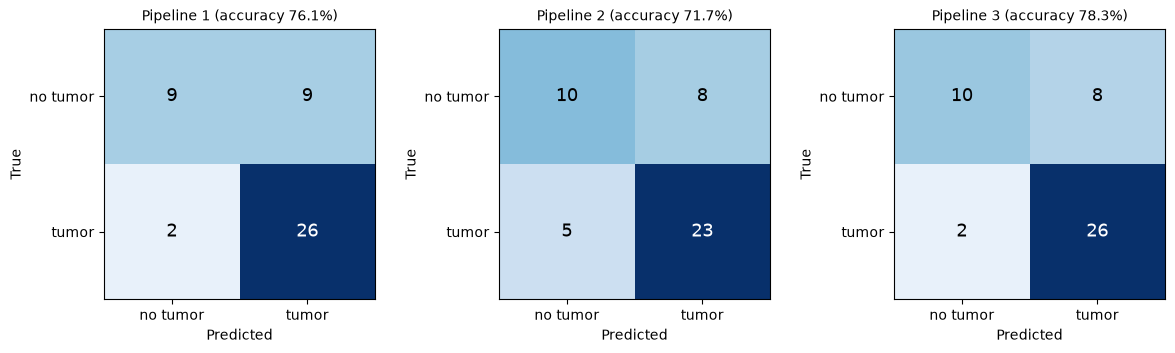

In [8]:
plot_confusion_matrices(
    {p.name: np.array(results[p.key]["confusion_matrix"]) for p in PIPELINES}, CLASS_NAMES
)
plt.show()

## 5. Takeaways

* **Pipeline 3** describes the *shape* of the Otsu mask with HOG and separates the
  classes best. Its training accuracy is far above its test accuracy because 8100
  features are learned from fewer than 200 training images.
* **Pipeline 2** gives GLCM four gray levels instead of a binary mask, but it
  overfits more than Pipeline 1 rather than generalising better.
* All pipelines find tumors reliably. Most errors are healthy scans classified
  as tumors.
* The test set has only 46 images, so one misclassified scan changes accuracy by
  about 2 percentage points. The nested cross-validation numbers in the README
  (Pipeline 1: 73.1%, Pipeline 2: 68.8%, Pipeline 3: 80.5%) are the more
  reliable comparison.